In [46]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go


In [47]:
alpha_0 = 1 + 1j
m = 1.0
h_bar = 1.0
omega = 1.0

In [48]:
def alpha(t):
    global alpha_0
    return alpha_0 * np.exp(-1j*omega*t)
    
def x_bar(t):
    return np.sqrt(2 * h_bar / (m * omega)) * np.real(alpha(t))
    
def psi_sq(x, t):
    prefactor = np.sqrt(m * omega / (np.pi * h_bar))
    return prefactor * np.exp((-m * omega / h_bar) * (x - x_bar(t))**2)

In [49]:
num_x = 200
num_z = 200  

x_max = 3.0
x = np.linspace(-x_max, x_max, num_x)
t_max = 2 * np.pi / omega 
z = np.linspace(0.0, t_max, num_z) 

X, Z = np.meshgrid(x, z)  

I_xt = psi_sq(X, Z) 

# Add cosine wave with no gaussian


X_mm = X * 1e3       
Z_ms = Z * 1e3

fig = go.Figure(data=[go.Surface(x=X_mm, y=Z_ms, z=I_xt,
                                 colorscale='Inferno', cmin=0, cmax=np.max(I_xt))])

fig.update_layout(title='Coherent state probability density |psi(x,t)|^2',
                  scene=dict(xaxis_title='x (mm)',
                             yaxis_title='t (ms)',
                             zaxis_title='Probability density (a.u.)',
                             aspectratio=dict(x=1.2, y=1.2, z=0.6)),
                  width=900, height=700)

fig.show()


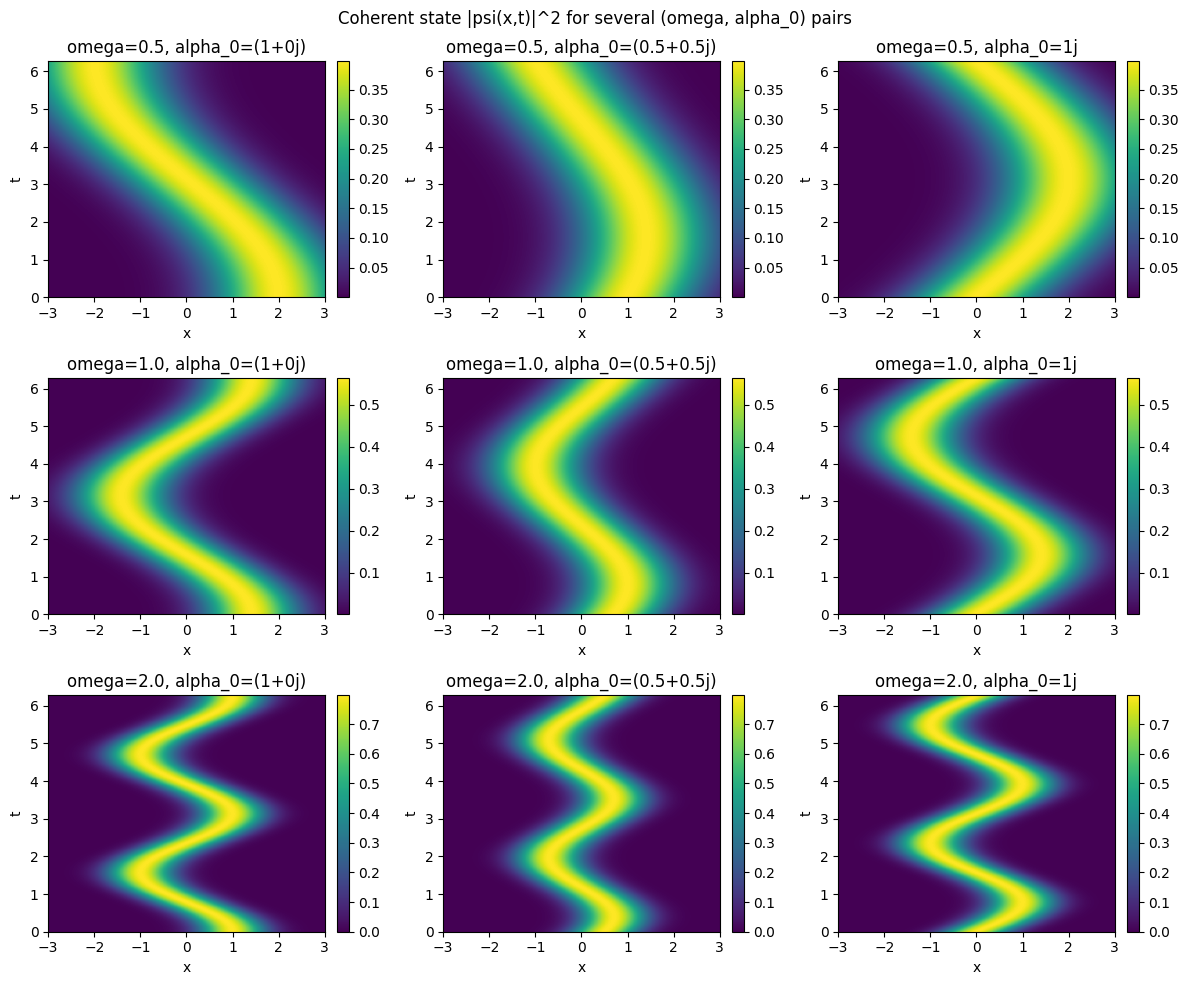

In [50]:
alpha_0 = 1 + 0j


def alpha_custom(t, omega, a_0):
    return a_0 * np.exp(-1j * omega * t)

def x_bar_custom(t, m, omega, h_bar, a_0):
    return np.sqrt(2 * h_bar / (m * omega)) * np.real(alpha_custom(t, omega, a_0))

def psi_sq_custom(x, t, m, omega, h_bar, a_0):
    prefactor = np.sqrt(m * omega / (np.pi * h_bar))
    return prefactor * np.exp((-m * omega / h_bar) * (x - x_bar_custom(t, m, omega, h_bar, a_0))**2)



omega_values = [0.5, 1.0, 2.0]
alpha_values = [1 + 0j, 0.5 + 0.5j, 1j] 


m = 1.0
h_bar = 1.0

num_x = 200
num_z = 200
x_max = 3.0

x = np.linspace(-x_max, x_max, num_x)

t_max = 4 * np.pi / max(omega_values)
z = np.linspace(0.0, t_max, num_z)

X, Z = np.meshgrid(x, z)

fig, axes = plt.subplots(len(omega_values), len(alpha_values), figsize=(12, 10))
fig.suptitle("Coherent state |psi(x,t)|^2 for several (omega, alpha_0) pairs")

for i, omega in enumerate(omega_values):
    for j, a_0 in enumerate(alpha_values):
        I_xt = psi_sq_custom(X, Z, m, omega, h_bar, a_0)
        ax = axes[i, j]
        im = ax.imshow(
            I_xt,
            origin="lower",
            extent=[x.min(), x.max(), z.min(), z.max()],
            aspect="auto"
        )
        ax.set_title(f"omega={omega}, alpha_0={a_0}")
        ax.set_xlabel("x")
        ax.set_ylabel("t")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
